In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load Data dari penyimpanan Colab
file_path = "/content/Dataset_ecommerce_500_Final_With_URL.xlsx"
df = pd.read_excel(file_path)

print("--- AUDIT STRUKTUR DATA ---")
df.info()

--- AUDIT STRUKTUR DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   ID Produk                          500 non-null    object
 1   Nama Produk                        500 non-null    object
 2   Brand                              500 non-null    object
 3   Kategori                           500 non-null    object
 4   Subkategori                        500 non-null    object
 5   Deskripsi Teks (Untuk Embeddings)  500 non-null    object
 6   Harga (Untuk Filter Metadata)      500 non-null    int64 
 7   URL Produk (Tautan Pembelian)      500 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.4+ KB


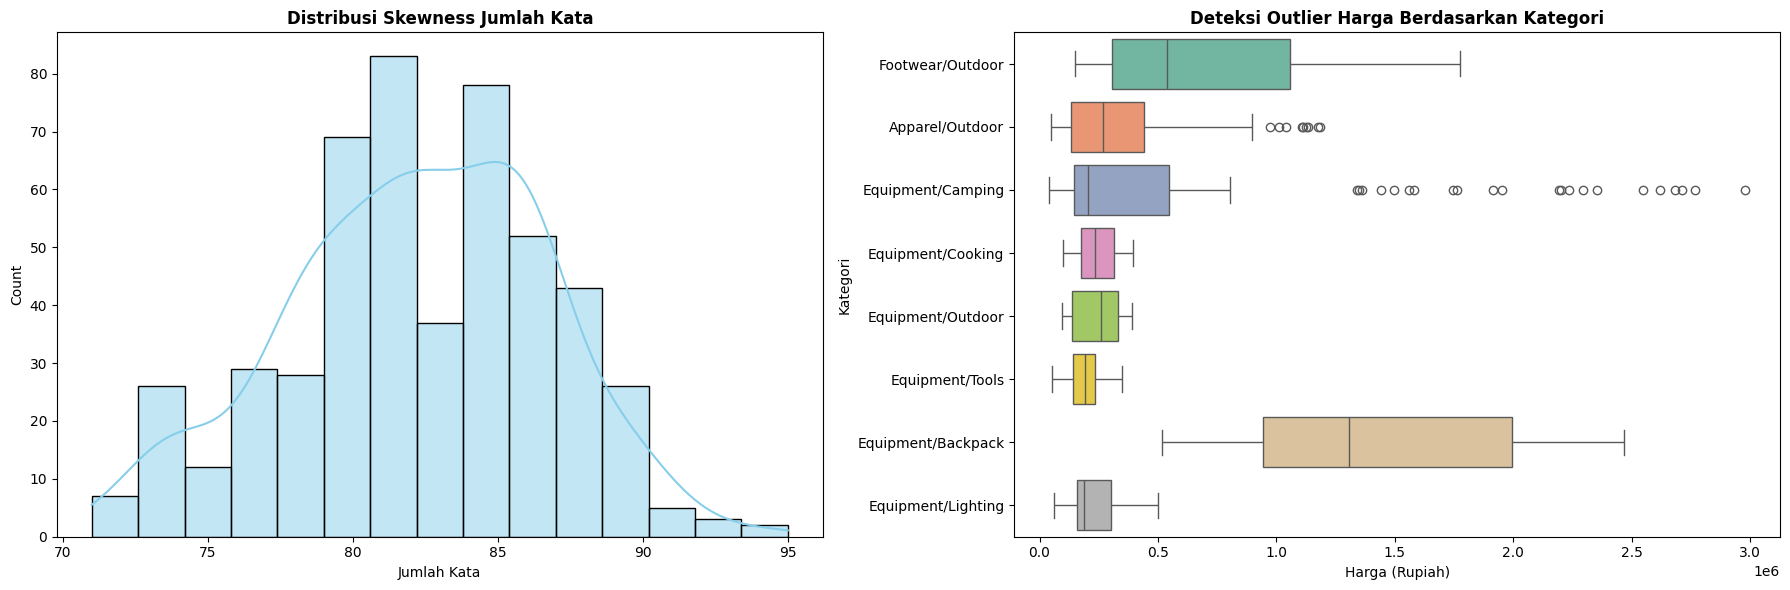

In [5]:
# Analisis Distribusi Panjang String (Token Efficiency)
desc_col = 'Deskripsi Teks (Untuk Embeddings)'
df['Word_Count'] = df[desc_col].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Word_Count'], bins=15, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Skewness Jumlah Kata', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')

harga_col = 'Harga (Untuk Filter Metadata)'
kategori_col = 'Kategori'
sns.boxplot(x=harga_col, y=kategori_col, data=df, palette='Set2', hue=kategori_col, legend=False, ax=axes[1])
axes[1].set_title('Deteksi Outlier Harga Berdasarkan Kategori', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Harga (Rupiah)')

plt.tight_layout()
plt.show()

In [6]:
print("--- AUDIT MISSING VALUES (SEBELUM) ---")
print(df.isnull().sum())

# Hard-Filtering Imputation Strategy
kolom_wajib = ['Deskripsi Teks (Untuk Embeddings)', 'Nama Produk']
df = df.dropna(subset=kolom_wajib)

kolom_kategori = ['Brand', 'Kategori', 'Subkategori']
for col in kolom_kategori:
    df[col] = df[col].fillna("Tidak Diketahui")

df[harga_col] = df.groupby('Kategori')[harga_col].transform(
    lambda x: x.fillna(x.median())
)
df[harga_col] = df[harga_col].fillna(df[harga_col].median())

print("\n--- AUDIT MISSING VALUES (SESUDAH) ---")
print(df.isnull().sum())

# Ekspor dataset yang sudah bersih ke lingkungan Colab
df.to_csv("/content/cleaned_dataset.csv", index=False)
print("\nDataset bersih berhasil dibuat!")

--- AUDIT MISSING VALUES (SEBELUM) ---
ID Produk                            0
Nama Produk                          0
Brand                                0
Kategori                             0
Subkategori                          0
Deskripsi Teks (Untuk Embeddings)    0
Harga (Untuk Filter Metadata)        0
URL Produk (Tautan Pembelian)        0
Word_Count                           0
dtype: int64

--- AUDIT MISSING VALUES (SESUDAH) ---
ID Produk                            0
Nama Produk                          0
Brand                                0
Kategori                             0
Subkategori                          0
Deskripsi Teks (Untuk Embeddings)    0
Harga (Untuk Filter Metadata)        0
URL Produk (Tautan Pembelian)        0
Word_Count                           0
dtype: int64

Dataset bersih berhasil dibuat!
